# 股指单日静态拟合：线性调试版

本 Notebook 从上到下依次执行 Task0 至 Task15。

- 不使用主流程封装或 Task 函数；所有步骤直接在线性单元格中执行。
- 仅重复使用的底层能力定义为辅助函数。
- 普通错误保留原始 traceback；数据校验失败直接抛出异常并停止。
- 修复后可从失败单元格重新运行；不重新执行 Task0 时继续复用同一运行目录。

## 环境与依赖

当前工作目录必须是本 Notebook 所在的 `test/`。

- IFIND Refresh Token：`test/.env` 中的 `IFIND_REFRESH_TOKEN`
- 迅投 Token：下方配置单元格中的 `XTQUANT_TOKEN`
- 原始可调用代码：`test/CSI/csiweb/`、`test/nas_reader/`
- 参考文件仍位于项目根目录，不会被本 Notebook 导入调用。

In [ ]:
from __future__ import annotations

import json
import math
import os
import re
import sys
import time
import pickle
import warnings
from datetime import date, datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()

# from ifind_import_helpers import (
#     INDEX_META,
#     fetch_etf_list,
#     fetch_ex_dividend,
#     fetch_limit_up_down_status,
#     fetch_snap_shot,
#     filter_listed_etfs,
#     get_access_token,
#     get_prior_trade_date,
#     load_dotenv,
#     save_table,
# )

BASE_URL = "https://quantapi.51ifind.com/api/v1"

# ========== 指数配置：改 INDEX_CODE 即可切换 ==========
# INDEX_CODE = "000016"  # 上证50
INDEX_CODE = "000300"  # 沪深300
# INDEX_CODE = "000905"  # 中证500
# INDEX_CODE = "000852"  # 中证1000
# INDEX_CODE = "000688"  # 科创50

INDEX_META = {
    "000016": {"name": "上证50", "ths": "000016.SH", "futures": "IH00.CFE", "primary_etf": "510050.SH"},
    "000300": {"name": "沪深300", "ths": "000300.SH", "futures": "IF00.CFE", "primary_etf": "510300.SH"},
    "000905": {"name": "中证500", "ths": "000905.SH", "futures": "IC00.CFE", "primary_etf": "510500.SH"},
    "000852": {"name": "中证1000", "ths": "000852.SH", "futures": "IM00.CFE", "primary_etf": "512100.SH"},
    "000688": {"name": "科创50", "ths": "000688.SH", "futures": "IC00.CFE", "primary_etf": "588000.SH"},
}

EX_DIVIDEND_COLUMN_MAP = {
    "thscode": "股票代码",
    "time": "报告期_财报期末",
    "ths_ex_dividend_date_stock": "除权除息日",
    "ths_dividend_ps_before_tax_stock": "每股派息_税前",
    "ths_bonus_shares_ps_stock": "每股送股",
}

LIMIT_STATUS_COLUMN_MAP = {
    "thscode": "股票代码",
    "time": "状态日期",
    "ths_up_and_down_status_stock": "涨跌停状态",
    "is_limit_up": "前日是否涨停",
    "is_limit_down": "前日是否跌停",
    "is_suspended": "前日是否停牌",
    "can_trade_today_hint": "今日交易参考",
}

SSE_QUERY_URL = "https://query.sse.com.cn/commonQuery.do"
SSE_REFERER = "https://www.sse.com.cn/disclosure/fund/etflist/"
SSE_COMPONENT_SQL_ID = "COMMON_SSE_CP_JJLB_ETFJJGK_GGSGSHQD_COMPONENT_C"

INDEX_UNITS = 14
CONTRACT_MULTIPLIER = 300.0
PRIMARY_ETF_CODE = None
PRICE_TOLERANCE = 0.0001
XTQUANT_TOKEN = "861456bdac24795078b34c94835ac4db1183bb3d"
XTQUANT_ADDRESS_POOL = [
    "115.231.218.73:55310", "115.231.218.79:55310",
    "36.99.48.20:55300", "36.99.48.21:55300",
    "42.228.16.210:55300", "42.228.16.211:55300",
]

# 外部接口字段发生变化时，应在现场检查实际字段后显式修改这些配置。
SSE_STOCK_CODE_FIELD = "COMPONENT_CODE"
SSE_COMPONENT_QTY_FIELD = "COMPONENT_QTY"
XT_STOCK_CODE_FIELD = "成份股代码"
XT_COMPONENT_QTY_FIELD = "股票数量"

if INDEX_CODE not in INDEX_META:
    raise RuntimeError(f"ifind_import_helpers.INDEX_META 未配置指数 {INDEX_CODE}")
index_meta = INDEX_META[INDEX_CODE]
index_name = index_meta["name"]
print("项目目录:", PROJECT_ROOT)
print("参数:", INDEX_CODE, index_name, INDEX_UNITS, CONTRACT_MULTIPLIER, PRIMARY_ETF_CODE)


项目目录: E:\Codex\系统\Stock-Index-Fitting
参数: 000300 沪深300 14 300.0 None


In [2]:
from utils import (read_daily_data, download_csi_constituent, read_csi_file, build_run_paths, read_stocks_ticks,
                   SseEtfPcfScraper, print_preview, resolve_sse50_etf_codes, save_outputs, download_csi_constituent_v02,
                   fetch_szse_pcf, calculate_exposure_deviation, build_index_tick, compute_tracking_error, plot_tracking)
from utils import safe_query as gogoal_query

## 重复使用的辅助函数

In [3]:
def to_xt_stock_code(code) -> str:
    text = str(code).strip()
    if "." in text:
        left, right = text.split(".", 1)
        return f"{left.zfill(6)}.{right.upper()}"

    code6 = text.zfill(6)
    if code6.startswith(("6", "9")):
        return f"{code6}.SH"
    if code6.startswith(("0", "2", "3")):
        return f"{code6}.SZ"
    if code6.startswith(("4", "8")):
        return f"{code6}.BJ"
    raise ValueError(f"无法识别证券代码市场: {code}")

def normalize_stock_code(value) -> str:
    raw = str(value).strip().upper()
    if raw.endswith((".SH", ".SZ", ".BJ")):
        return raw
    digits = raw.split(".")[0].zfill(6)
    return f"{digits}.SH" if digits.startswith(("5", "6", "9")) else f"{digits}.SZ"


def require_columns(frame: pd.DataFrame, columns: list[str], label: str) -> None:
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise RuntimeError(f"{label} 缺少明确字段 {missing}；实际字段={frame.columns.tolist()}")


def save_csv(frame: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"已保存: {path} shape={frame.shape}")


def show_frame(label: str, frame: pd.DataFrame, rows: int = 5) -> None:
    print(f"{label}: shape={frame.shape}")
    print("字段:", frame.columns.tolist())
    display(frame.head(rows))


def floor_legal_quantity(quantity: float, minimum: int, step: int) -> int:
    if quantity < minimum:
        return 0
    return int(minimum + math.floor((quantity - minimum) / step) * step)


def sql_literal(value) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def sql_in(values) -> str:
    vals = list(values)
    if not vals:
        raise ValueError("SQL IN 列表为空")
    return ", ".join(sql_literal(v) for v in vals)


def strip_market_suffix(value) -> str:
    return str(value).strip().upper().split(".")[0].zfill(6)


def normalize_trade_date(value) -> str:
    return pd.Timestamp(value).strftime("%Y%m%d")


def normalize_trade_date_dash(value) -> str:
    return pd.Timestamp(value).strftime("%Y-%m-%d")



def fetch_gogoal_index_close(index_code: str, trade_date: str) -> pd.DataFrame:
    sql = f"""
        SELECT trade_date, index_code, index_name, tclose, lclose, is_valid
        FROM qt_idx_daily
        WHERE index_code = {sql_literal(index_code)}
          AND trade_date = {sql_literal(normalize_trade_date_dash(trade_date))}
          AND is_valid = 1
    """
    return gogoal_query(sql, output_format="dataframe")


def fetch_gogoal_stock_closes(stock_codes: list[str], trade_date: str) -> pd.DataFrame:
    stripped_codes = [strip_market_suffix(code) for code in stock_codes]
    sql = f"""
        SELECT trade_date, stock_code, stock_name, tclose, lclose, is_valid
        FROM qt_stk_daily
        WHERE trade_date = {sql_literal(normalize_trade_date_dash(trade_date))}
          AND stock_code IN ({sql_in(stripped_codes)})
          AND is_valid = 1
    """
    raw = gogoal_query(sql, output_format="dataframe")
    if raw.empty:
        return pd.DataFrame(columns=["stock_code", "gogoal_close", "gogoal_lclose", "stock_name_gogoal"])
    raw["stock_code"] = raw["stock_code"].map(normalize_stock_code)
    return raw.rename(columns={
        "stock_name": "stock_name_gogoal",
        "tclose": "gogoal_close",
        "lclose": "gogoal_lclose",
    })[["stock_code", "stock_name_gogoal", "gogoal_close", "gogoal_lclose"]]


def fetch_gogoal_corporate_actions(stock_codes: list[str], start_date: str, end_date: str) -> pd.DataFrame:
    stripped_codes = [strip_market_suffix(code) for code in stock_codes]
    sql = f"""
        SELECT
            stock_code,
            stock_name,
            declare_date,
            xr_xd_date AS ex_date,
            beftax_maxcashdiv,
            beftax_mincashdiv,
            aftax_cashdiv,
            stockdiv_ratio,
            trans_ratio,
            bonus_ratio,
            is_newest,
            is_valid
        FROM bas_stk_hisdistribution
        WHERE stock_code IN ({sql_in(stripped_codes)})
          AND xr_xd_date >= {sql_literal(normalize_trade_date_dash(start_date))}
          AND xr_xd_date <= {sql_literal(normalize_trade_date_dash(end_date))}
          AND is_valid = 1
    """
    raw = gogoal_query(sql, output_format="dataframe")
    if raw.empty:
        return pd.DataFrame(columns=["stock_code", "ex_date"])
    raw["stock_code"] = raw["stock_code"].map(normalize_stock_code)
    raw["ex_date"] = pd.to_datetime(raw["ex_date"], errors="coerce").dt.strftime("%Y-%m-%d")
    return raw


## Task0：初始化运行环境

In [4]:
#Task0
if not re.fullmatch(r"\d{6}", INDEX_CODE):
    raise ValueError("INDEX_CODE 必须为六位数字字符串")
if not isinstance(INDEX_UNITS, int) or isinstance(INDEX_UNITS, bool) or INDEX_UNITS <= 0:
    raise ValueError("INDEX_UNITS 必须为正整数")
if not isinstance(CONTRACT_MULTIPLIER, (int, float)) or CONTRACT_MULTIPLIER <= 0:
    raise ValueError("CONTRACT_MULTIPLIER 必须为正数")

started_at = datetime.now().astimezone()
import_time = started_at.strftime("%Y%m%d-%H%M")
run_dir = PROJECT_ROOT / "data" / INDEX_CODE / import_time
directory_names = [
    "01_index", "02_etf", "03_corporate_actions", "04_market",
    "05_trading_status", "06_trading_rules", "reports", "logs",
]
dirs = {name: run_dir / name for name in directory_names}
for directory in dirs.values():
    directory.mkdir(parents=True, exist_ok=True)

paths = {
    "index_weights": dirs["01_index"] / "index_weights.csv",
    "index_cons": dirs["01_index"] / "index_cons.csv",
    "index_check": dirs["01_index"] / "index_constituents_check.csv",
    "related_etfs": dirs["02_etf"] / "related_etfs.csv",
    "sse_pcf": dirs["02_etf"] / "sse_etf_components.csv",
    "xt_pcf": dirs["02_etf"] / "xt_etf_components.csv",
    "etf_check": dirs["02_etf"] / "etf_cross_check.csv",
    "actions_gogoal": dirs["03_corporate_actions"] / "corporate_actions_gogoal.csv",
    "actions_xt": dirs["03_corporate_actions"] / "corporate_actions_xt.csv",
    "actions_check": dirs["03_corporate_actions"] / "corporate_actions_cross_check.csv",
    "actions_ifind": dirs["03_corporate_actions"] / "corporate_actions_ifind.csv",
    "actions_merged": dirs["03_corporate_actions"] / "corporate_actions_merged.csv",
    "market_snapshot": dirs["04_market"] / "market_snapshot.csv",
    "market_gogoal": dirs["04_market"] / "market_gogoal.csv",
    "trading_status": dirs["05_trading_status"] / "trading_status.csv",
    "security_rules": dirs["06_trading_rules"] / "security_rules.csv",
    "rule_candidates": dirs["06_trading_rules"] / "rule_parser_candidates.csv",
    "component_rules": dirs["06_trading_rules"] / "component_rules.csv",
    "theoretical": dirs["reports"] / "theoretical_portfolio.csv",
    "target": dirs["reports"] / "target_portfolio.csv",
    "deviation": dirs["reports"] / "deviation_report.csv",
    "portfolio_summary": dirs["reports"] / "portfolio_summary.csv",
    "run_summary": dirs["reports"] / "run_summary.csv",
    "report_xlsx": dirs["reports"] / "report.xlsx",
}
print("import_time:", import_time)
print("run_dir:", run_dir)


import_time: 20260629-1359
run_dir: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359


## Task1：初始化迅投与 IFIND 连接

In [5]:
#Task1
from xtquant import xtdatacenter as xtdc
from xtquant import xtdata
xtdata.reconnect(port = 58610)

# ENV_FILE = PROJECT_ROOT / ".env"
# load_dotenv(ENV_FILE)
# ifind_refresh_token = os.environ.get("IFIND_REFRESH_TOKEN", "").strip()
# if not ifind_refresh_token:
#     raise RuntimeError(f"请在 {ENV_FILE} 中配置 IFIND_REFRESH_TOKEN")
# IFIND_ACCESS_TOKEN = get_access_token(ifind_refresh_token)
# print("XtQuant data_dir:", xtdata.data_dir)
# print("IFIND access token 获取成功（Token 不展示）")


***** xtdata连接成功 2026-06-29 14:03:00*****
服务信息: {'tag': 'qmt_research', 'version': '1.0'}
服务地址: 127.0.0.1:58610
数据路径: E:\迅投极速交易终端睿智融科版\datadir
设置xtdata.enable_hello = False可隐藏此消息



## Task2：通过 **迅投** 交易日历确定构建日

In [6]:
#Task2
index_exchange = index_meta["ths"].split(".")[-1]
xt_index_code = index_meta["ths"]
ifind_index_code = index_meta["ths"]

# 直接使用已验证 helper：以运行自然日为基准，取严格早于它的最近交易日。
today_datetime = datetime.now()
today_ymd = today_datetime.strftime("%Y%m%d")
today_dash = today_datetime.strftime("%Y-%m-%d")

dates = pd.to_datetime(xtdata.get_trading_dates("SH"), unit="ms").strftime("%Y-%m-%d").tolist()[-2:]

build_date_dash = dates[1]
build_date = build_date_dash.replace("-", "")

previous_trade_date_dash = dates[0]
previous_trade_date = previous_trade_date_dash.replace("-", "")
# build_date, build_date_dash = get_prior_trade_date(IFIND_ACCESS_TOKEN, today_ymd, today_dash)
# previous_trade_date, previous_trade_date_dash = get_prior_trade_date(
#     IFIND_ACCESS_TOKEN, build_date, build_date_dash
# )
if not build_date < today_ymd or not previous_trade_date < build_date:
    raise RuntimeError(
        f"交易日顺序异常: previous={previous_trade_date}, build={build_date}, today={today_ymd}"
    )

# 使用参考 Notebook 配套的 dataset_layout，保留 IFIND 数据集轨目录。
# ifind_run_paths = build_run_paths(INDEX_CODE, index_name, build_date, PROJECT_ROOT)
print("运行自然日:", today_ymd)
print("构建日:", build_date, build_date_dash)
print("前一交易日:", previous_trade_date, previous_trade_date_dash)
# print("IFIND 数据集轨:", ifind_run_paths.run_dir)


运行自然日: 20260629
构建日: 20260628 2026-06-28
前一交易日: 20260625 2026-06-25


In [7]:
build_date = "20260622"
build_date_dash = "2026-06-22"
previous_trade_date = "20260619"
previous_trade_date_dash = "2026-06-19"

## Task2B 


In [ ]:

# #Task2-GoGoal
# gogoal_exchange_code_map = {
#     "SH": "001001",
#     "SZ": "001002",
# }
# gogoal_exchange_code = gogoal_exchange_code_map.get(index_exchange)
# if not gogoal_exchange_code:
#     raise RuntimeError(f"Go-Goal calendar does not support index exchange: {index_exchange}")

# today_for_gogoal_dash = today_dash if "today_dash" in globals() else datetime.now().strftime("%Y-%m-%d")
# today_for_gogoal_ymd = today_ymd if "today_ymd" in globals() else datetime.now().strftime("%Y%m%d")

# df_gogoal_today_calendar = gogoal_query(f"""
# SELECT exchange, trade_date, is_trade_date, vtrade_date, ltrade_date, ntrade_date, is_valid
# FROM qt_trade_date
# WHERE exchange = {sql_literal(gogoal_exchange_code)}
#   AND trade_date = {sql_literal(today_for_gogoal_dash)}
#   AND is_valid = 1
# LIMIT 1
# """, output_format="dataframe")

# if df_gogoal_today_calendar.empty:
#     df_gogoal_build = gogoal_query(f"""
# SELECT exchange, trade_date, is_trade_date, vtrade_date, ltrade_date, ntrade_date, is_valid
# FROM qt_trade_date
# WHERE exchange = {sql_literal(gogoal_exchange_code)}
#   AND trade_date < {sql_literal(today_for_gogoal_dash)}
#   AND is_trade_date = 1
#   AND is_valid = 1
# ORDER BY trade_date DESC
# LIMIT 1
# """, output_format="dataframe")
#     if df_gogoal_build.empty:
#         raise RuntimeError(f"Go-Goal cannot determine a build date before {today_for_gogoal_dash}")
#     gogoal_build_date_dash = normalize_trade_date_dash(df_gogoal_build["trade_date"].iloc[0])
# else:
#     gogoal_ltrade = df_gogoal_today_calendar["ltrade_date"].iloc[0]
#     if pd.isna(gogoal_ltrade):
#         raise RuntimeError(f"Go-Goal calendar row has empty ltrade_date: {today_for_gogoal_dash}")
#     gogoal_build_date_dash = normalize_trade_date_dash(gogoal_ltrade)

# df_gogoal_build_calendar = gogoal_query(f"""
# SELECT exchange, trade_date, is_trade_date, vtrade_date, ltrade_date, ntrade_date, is_valid
# FROM qt_trade_date
# WHERE exchange = {sql_literal(gogoal_exchange_code)}
#   AND trade_date = {sql_literal(gogoal_build_date_dash)}
#   AND is_valid = 1
# LIMIT 1
# """, output_format="dataframe")
# if df_gogoal_build_calendar.empty:
#     raise RuntimeError(f"Go-Goal cannot read build-date calendar row: {gogoal_build_date_dash}")

# gogoal_previous_trade_date_dash = normalize_trade_date_dash(df_gogoal_build_calendar["ltrade_date"].iloc[0])
# gogoal_build_date = pd.Timestamp(gogoal_build_date_dash).strftime("%Y%m%d")
# gogoal_previous_trade_date = pd.Timestamp(gogoal_previous_trade_date_dash).strftime("%Y%m%d")

# if not gogoal_build_date < today_for_gogoal_ymd or not gogoal_previous_trade_date < gogoal_build_date:
#     raise RuntimeError(
#         f"Go-Goal calendar order error: previous={gogoal_previous_trade_date}, "
#         f"build={gogoal_build_date}, today={today_for_gogoal_ymd}"
#     )

# print("Go-Goal natural date:", today_for_gogoal_ymd)
# print("Go-Goal build date:", gogoal_build_date, gogoal_build_date_dash)
# print("Go-Goal previous trade date:", gogoal_previous_trade_date, gogoal_previous_trade_date_dash)
# if "build_date" in globals():
#     print("Matches IFIND build date:", gogoal_build_date == build_date)
# if "previous_trade_date" in globals():
#     print("Matches IFIND previous trade date:", gogoal_previous_trade_date == previous_trade_date)
# display(df_gogoal_today_calendar)
# display(df_gogoal_build_calendar)


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库
正在尝试first_config连接: 192.168.1.30:3306


Go-Goal natural date: 20260618
Go-Goal build date: 20260617 2026-06-17
Go-Goal previous trade date: 20260616 2026-06-16
Matches IFIND build date: True
Matches IFIND previous trade date: True


成功使用first_config连接数据库


,exchange,trade_date,is_trade_date,vtrade_date,ltrade_date,ntrade_date,is_valid
0,001001,2026-06-18,1,2026-06-18,2026-06-17,2026-06-22,1


,exchange,trade_date,is_trade_date,vtrade_date,ltrade_date,ntrade_date,is_valid
0,001001,2026-06-17,1,2026-06-17,2026-06-16,2026-06-18,1


In [ ]:
# 查询 Go-Goal 申万二级行业分类
# 中信二级 950 申万二级 444
sql_sw_l2_industry = """
SELECT
    stock_code,
    stock_name,
    industry_code,
    industry_name
FROM qt_indus_constituents
WHERE is_valid = 1
  AND use_status = 1
  AND standard_code = '444'
  AND industry_level = 2
"""
def to_xt_code(stock_code: str) -> str:
    code = str(stock_code).zfill(6)
    if code.startswith(("6", "9")):
        return f"{code}.SH"
    if code.startswith(("0", "2", "3")):
        return f"{code}.SZ"
    if code.startswith(("4", "8")):
        return f"{code}.BJ"
    raise ValueError(f"无法识别股票市场: {code}")

df_sw_l2_industry = gogoal_query(sql_sw_l2_industry, output_format="dataframe")

if df_sw_l2_industry.empty:
    raise RuntimeError("Go-Goal 未查询到申万二级行业分类数据")

df_sw_l2_industry["stock_code"] = df_sw_l2_industry["stock_code"].astype(str).str.zfill(6)
df_sw_l2_industry["xt_stock_code"] = df_sw_l2_industry["stock_code"].map(to_xt_stock_code)

df_sw_l2_industry = df_sw_l2_industry[
    ["xt_stock_code", "stock_code", "stock_name", "industry_code", "industry_name"]
].drop_duplicates()

正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


In [12]:
display(df_sw_l2_industry.sort_values("industry_code").reset_index(drop=True))
print("申万二级行业分类记录数:", len(df_sw_l2_industry))

,xt_stock_code,stock_code,stock_name,industry_code,industry_name
0,600265.SH,600265,ST景谷,801011,林业
1,000663.SZ,000663,永安林业,801011,林业Ⅱ
2,000592.SZ,000592,平潭发展,801011,林业
3,002679.SZ,002679,福建金森,801011,林业
4,001338.SZ,001338,永顺泰,801012,农产品加工
...,...,...,...,...,...
5525,300770.SZ,300770,新媒股份,801995,电视广播Ⅱ
5526,600959.SH,600959,江苏有线,801995,电视广播Ⅱ
5527,600637.SH,600637,东方明珠,801995,电视广播Ⅱ
5528,000665.SZ,000665,湖北广电,801995,电视广播Ⅱ


申万二级行业分类记录数: 5530


## Task3：下载、读取并校验 CSI 权重与成分

In [8]:
# Task3
weight_file = download_csi_constituent_v02(INDEX_CODE, str(dirs["01_index"]), "closeweight")
cons_file = download_csi_constituent_v02(INDEX_CODE, str(dirs["01_index"]), "cons")
if not weight_file or not cons_file:
    raise RuntimeError("CSI closeweight or constituents file download failed")
raw_weights = read_csi_file(weight_file)
raw_cons = read_csi_file(cons_file)
if raw_weights is None or raw_cons is None or raw_weights.empty or raw_cons.empty:
    raise RuntimeError("CSI closeweight or constituents file is empty or cannot be parsed")

CSI_DATE_FIELD = raw_weights.columns[0]
CSI_CONS_DATE_FIELD = raw_cons.columns[0]
CSI_CODE_FIELD = "\u6210\u4efd\u5238\u4ee3\u7801Constituent Code"
CSI_NAME_FIELD = "\u6210\u4efd\u5238\u540d\u79f0Constituent Name"
CSI_WEIGHT_FIELD = "\u6743\u91cd(%)weight"
require_columns(raw_weights, [CSI_DATE_FIELD, CSI_CODE_FIELD, CSI_NAME_FIELD, CSI_WEIGHT_FIELD], "CSI closeweight")
require_columns(raw_cons, [CSI_CONS_DATE_FIELD, CSI_CODE_FIELD, CSI_NAME_FIELD], "CSI constituents")


def extract_single_csi_data_date(frame: pd.DataFrame, label: str) -> str:
    date_col = frame.columns[0]
    parsed_dates = []
    for value in frame[date_col].dropna().unique():
        raw = str(value).strip()
        if re.fullmatch(r"\d{8}", raw):
            parsed = pd.to_datetime(raw, format="%Y%m%d", errors="coerce")
        else:
            parsed = pd.to_datetime(value, errors="coerce")
        if pd.notna(parsed):
            parsed_dates.append(pd.Timestamp(parsed).strftime("%Y-%m-%d"))
    unique_dates = sorted(set(parsed_dates))
    if len(unique_dates) != 1:
        raise RuntimeError(f"{label} first-column date is not unique: {unique_dates}")
    return unique_dates[0]

closeweight_data_date = extract_single_csi_data_date(raw_weights, "CSI closeweight file")
cons_data_date = extract_single_csi_data_date(raw_cons, "CSI constituents file")

df_index_weights = pd.DataFrame({
    "stock_code": raw_weights[CSI_CODE_FIELD].map(normalize_stock_code),
    "stock_name": raw_weights[CSI_NAME_FIELD].astype(str).str.strip(),
    "raw_weight_pct": pd.to_numeric(raw_weights[CSI_WEIGHT_FIELD], errors="coerce"),
    "closeweight_data_date": closeweight_data_date,
    "import_time": import_time,
})
df_index_cons = pd.DataFrame({
    "stock_code": raw_cons[CSI_CODE_FIELD].map(normalize_stock_code),
    "stock_name": raw_cons[CSI_NAME_FIELD].astype(str).str.strip(),
    "cons_data_date": cons_data_date,
    "import_time": import_time,
})
weight_set, cons_set = set(df_index_weights.stock_code), set(df_index_cons.stock_code)
if df_index_weights["raw_weight_pct"].isna().any() or (df_index_weights["raw_weight_pct"] < 0).any():
    raise RuntimeError("CSI closeweight contains null or negative weights")
if df_index_weights.stock_code.duplicated().any() or df_index_cons.stock_code.duplicated().any():
    raise RuntimeError("CSI files contain duplicated constituent codes")

df_index_check = pd.DataFrame([{
    "weight_count": len(weight_set),
    "cons_count": len(cons_set),
    "closeweight_data_date": closeweight_data_date,
    "cons_data_date": cons_data_date,
    "only_in_weights": "|".join(sorted(weight_set - cons_set)),
    "only_in_cons": "|".join(sorted(cons_set - weight_set)),
    "is_consistent": weight_set == cons_set,
    "closeweight_path": str(weight_file),
    "cons_path": str(cons_file),
    "import_time": import_time,
}])
save_csv(df_index_check, paths["index_check"])

if weight_set != cons_set:
    display(df_index_check)
    raise RuntimeError("CSI closeweight and constituents code sets are inconsistent")

save_csv(df_index_weights, paths["index_weights"])
save_csv(df_index_cons, paths["index_cons"])
stock_codes = df_index_weights["stock_code"].tolist()
show_frame("standardized CSI weights", df_index_weights)
show_frame("CSI closeweight/constituents check", df_index_check)
print("CSI closeweight data date:", closeweight_data_date)
print("CSI constituents data date:", cons_data_date)
print("raw weight sum, not normalized:", df_index_weights["raw_weight_pct"].sum())


正在下载指数 000300 样本权重...
解析到真实链接: https://oss-ch.csindex.com.cn/static/html/csindex/public/uploads/file/autofile/closeweightlintiao/20260615/000300closeweight.xls
下载完成: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\01_index\000300_样本权重_20260629.xls
正在下载指数 000300 样本列表...
解析到真实链接: https://oss-ch.csindex.com.cn/static/html/csindex/public/uploads/file/autofile/cons/000300cons.xls
下载完成: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\01_index\000300_成分股_20260629.xls
     日期Date  指数代码 Index Code 指数名称 Index Name 指数英文名称Index Name(Eng)  \
0  20260615              300           沪深300               CSI 300   
1  20260615              300           沪深300               CSI 300   
2  20260615              300           沪深300               CSI 300   
3  20260615              300           沪深300               CSI 300   
4  20260615              300           沪深300               CSI 300   

   成份券代码Constituent Code 成份券名称Constituent Name  \
0                      1                  平安

,stock_code,stock_name,raw_weight_pct,closeweight_data_date,import_time
0,000001.SZ,平安银行,0.386,2026-06-15,20260629-1359
1,000002.SZ,万科A,0.077,2026-06-15,20260629-1359
2,000063.SZ,中兴通讯,0.432,2026-06-15,20260629-1359
3,000100.SZ,TCL科技,0.346,2026-06-15,20260629-1359
4,000157.SZ,中联重科,0.136,2026-06-15,20260629-1359


CSI closeweight/constituents check: shape=(1, 10)
字段: ['weight_count', 'cons_count', 'closeweight_data_date', 'cons_data_date', 'only_in_weights', 'only_in_cons', 'is_consistent', 'closeweight_path', 'cons_path', 'import_time']


,weight_count,cons_count,closeweight_data_date,cons_data_date,only_in_weights,only_in_cons,is_consistent,closeweight_path,cons_path,import_time
0,300,300,2026-06-15,2026-06-26,,,True,E:\Codex\系统\Stock-Index-Fitting\data\000300\20...,E:\Codex\系统\Stock-Index-Fitting\data\000300\20...,20260629-1359


CSI closeweight data date: 2026-06-15
CSI constituents data date: 2026-06-26
raw weight sum, not normalized: 99.998


## Task4：获取相关 ETF 并严格验证主 ETF PCF

In [ ]:
# NOTEBOOK_DIR = Path.cwd()
# DATASET_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "_notebooks" else NOTEBOOK_DIR

# KEYWORDS = index_name
# ETF_CODES = []  # 留空自动搜索；或 ["510050"]

# scraper = SseEtfPcfScraper()
# # if ETF_CODES:
# #     codes, name_map = ETF_CODES, {}
# # else:
# #     codes, name_map = resolve_sse50_etf_codes(scraper, keywords=KEYWORDS)

# STOCK_ETF_CLASSES = ("01", "03", "08", "09")

# if ETF_CODES:
#     codes, name_map = ETF_CODES, {}
# else:
#     codes, name_map = resolve_sse50_etf_codes(
#         scraper,
#         keywords=KEYWORDS,
#         etf_classes=STOCK_ETF_CLASSES,
#     )

# print(f"待爬取: {codes}")
# df_components, df_basic, raw_payloads = scraper.scrape_etfs(codes, name_map)

# trade_date = str(df_basic["trading_day"].iloc[0]).replace("-", "") if not df_basic.empty else "unknown"
# out_dir = build_run_paths(INDEX_CODE, index_name, trade_date, DATASET_ROOT).category_dir("etf_pcf", "sse")
# paths_etf = save_outputs(df_components, df_basic, raw_payloads, out_dir, INDEX_CODE, trade_date)

# print_preview(df_components, df_basic)
# for k, p in paths_etf.items():
#     print(k, "→", p.relative_to(DATASET_ROOT))

待爬取: ['510300', '510310', '510320', '510330', '510350', '510360', '510370', '510380', '510390', '512010', '512070', '512530', '515130', '515300', '515310', '515330', '515350', '515360', '515380', '515390', '515660', '516830', '560180', '560330', '561000', '561300', '561900', '561930', '561990', '562070', '562080', '562310', '562320', '563520', '563900', '563960']

上交所 ETF 申赎清单 — 成份股信息 预览

[基本信息]
etf_code                    etf_name trading_day creation_redemption_unit     nav
  510300     华泰柏瑞沪深300交易型开放式指数证券投资基金  2026-06-18                   900000 ￥4.9582
  510310   易方达沪深300交易型开放式指数发起式证券投资基金  2026-06-18                   900000 ￥4.8056
  510320       中金沪深300交易型开放式指数证券投资基金  2026-06-18                  3000000 ￥1.3315
  510330       华夏沪深300交易型开放式指数证券投资基金  2026-06-18                   900000 ￥5.1658
  510350     工银瑞信沪深300交易型开放式指数证券投资基金  2026-06-18                   900000 ￥5.1853
  510360       广发沪深300交易型开放式指数证券投资基金  2026-06-18                  3000000 ￥1.8850
  510370       兴业沪深300交易型开放

In [10]:
# Task4 — ETF 申赎清单（SSE / SZSE 双源）
resolved_etf = PRIMARY_ETF_CODE or index_meta.get("primary_etf", "")
if not resolved_etf:
    warnings.warn(f"指数 {INDEX_CODE} 未配置 primary_etf，跳过 Task4。")
    print("⏭️ Task4 跳过")
else:
    print(f"主 ETF: {resolved_etf}")

    if resolved_etf.endswith(".SH"):
        etf_code_digits = resolved_etf.split(".")[0]
        scraper = SseEtfPcfScraper()
        try:
            df_components, df_basic, _ = scraper.scrape_etfs([etf_code_digits], {})
            if df_components.empty:
                ss.warn(f"SSE PCF 返回空: {resolved_etf}")
            else:
                df_pcf_out = df_components.rename(columns={
                    "证券代码": "stock_code",
                    "证券简称": "stock_name",
                    "股票数量_股": "component_qty",
                    "现金替代标志": "substitution_flag",
                })
                df_pcf_out["stock_code"] = df_pcf_out["stock_code"].map(normalize_stock_code)
                df_pcf_out["etf_code"] = resolved_etf
                df_pcf_out["source"] = "SSE"
                df_pcf_out["retrieved_at"] = datetime.now().isoformat()
                df_pcf_out["import_time"] = import_time
                out_cols = ["etf_code", "stock_code", "stock_name", "component_qty",
                           "substitution_flag", "source", "retrieved_at", "import_time"]
                df_pcf_out = df_pcf_out[[c for c in out_cols if c in df_pcf_out.columns]]
                save_csv(df_pcf_out, paths["sse_pcf"])
                show_frame("上交所主 ETF 申赎清单", df_pcf_out)
        except Exception as e:
            warnings.warn(f"SSE PCF 爬取失败（不阻断主流程）: {e}")

    elif resolved_etf.endswith(".SZ"):
        etf_code_digits = resolved_etf.split(".")[0]
        try:
            df_pcf_out = fetch_szse_pcf(etf_code_digits, build_date)
            df_pcf_out["stock_code"] = df_pcf_out["stock_code"].map(normalize_stock_code)
            df_pcf_out["import_time"] = import_time
            save_csv(df_pcf_out, paths["szse_pcf"])
            show_frame("深交所主 ETF 申赎清单", df_pcf_out)
        except Exception as e:
            warnings.warn(f"SZSE PCF 爬取失败（不阻断主流程）: {e}")
    else:
        warnings.warn(f"主 ETF 后缀无法识别: {resolved_etf}")


主 ETF: 510300.SH
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\02_etf\sse_etf_components.csv shape=(300, 8)
上交所主 ETF 申赎清单: shape=(300, 8)
字段: ['etf_code', 'stock_code', 'stock_name', 'component_qty', 'substitution_flag', 'source', 'retrieved_at', 'import_time']


,etf_code,stock_code,stock_name,component_qty,substitution_flag,source,retrieved_at,import_time
0,510300.SH,000001.SZ,平安银行,1500,允许,SSE,2026-06-29T14:03:21.312719,20260629-1359
1,510300.SH,000002.SZ,万科A,1100,允许,SSE,2026-06-29T14:03:21.312719,20260629-1359
2,510300.SH,000063.SZ,中兴通讯,500,允许,SSE,2026-06-29T14:03:21.312719,20260629-1359
3,510300.SH,000100.SZ,TCL科技,3300,允许,SSE,2026-06-29T14:03:21.312719,20260629-1359
4,510300.SH,000157.SZ,中联重科,800,允许,SSE,2026-06-29T14:03:21.312719,20260629-1359


In [11]:
# Task4：从迅投获取 ETF 申赎清单，并与官网爬取结果校验

# 模糊选择
# def _pick_col(frame: pd.DataFrame, candidates: list[str], label: str) -> str:
#     for col in candidates:
#         if col in frame.columns:
#             return col
#     raise RuntimeError(f"{label} 未找到字段，候选={candidates}，实际字段={list(frame.columns)}")

def to_xt_etf_code(code) -> str:
    text = str(code).strip()
    if "." in text:
        left, right = text.split(".", 1)
        return f"{left.zfill(6)}.{right.upper()}"

    code6 = text.zfill(6)
    if code6.startswith(("5", "6")):
        return f"{code6}.SH"
    if code6.startswith(("1", "15", "16", "18")):
        return f"{code6}.SZ"
    return to_xt_stock_code(code6)


# 1. 整理官网爬取的 PCF
# 模糊选择
# sse_code_col = _pick_col(
#     df_components,
#     ["证券代码", "成份券代码", "成分券代码", "INSTRUMENT_ID", "璇佸埜浠ｇ爜"],
#     "上交所 PCF 证券代码",
# )
# sse_qty_col = _pick_col(
#     df_components,
#     ["股票数量_股", "股票数量", "数量", "成份券数量", "QUANTITY", "鑲＄エ鏁伴噺_鑲?"],
#     "上交所 PCF 成份数量",
# )

sse_code_col = '证券代码'
sse_qty_col = '股票数量_股'

if "etf_code" not in df_components.columns:
    raise RuntimeError("官网 PCF 缺少 etf_code 字段，无法逐 ETF 与迅投校验")

df_sse_pcf_check = pd.DataFrame({
    "etf_code": df_components["etf_code"].map(to_xt_etf_code),
    "stock_code": df_components[sse_code_col].map(to_xt_stock_code),
    "component_qty_sse": pd.to_numeric(df_components[sse_qty_col], errors="coerce"),
})
df_sse_pcf_check = (
    df_sse_pcf_check
    .dropna(subset=["stock_code", "component_qty_sse"])
    .drop_duplicates(["etf_code", "stock_code"])
)

if df_sse_pcf_check.empty:
    raise RuntimeError("官网 PCF 整理后为空")


# 2. 获取迅投 PCF
xtdata.download_etf_info()
all_etf_info = xtdata.get_etf_info() or {}
if not all_etf_info:
    raise RuntimeError("迅投 get_etf_info 返回为空")

target_etf_codes = sorted(df_sse_pcf_check["etf_code"].dropna().unique())

xt_component_rows = []
missing_xt_etfs = []

for etf_code in target_etf_codes:
    xt_info = all_etf_info.get(etf_code)
    if xt_info is None:
        # 有些环境 key 可能只有 6 位代码
        xt_info = all_etf_info.get(etf_code.split(".")[0])

    if xt_info is None:
        missing_xt_etfs.append(etf_code)
        continue

    xt_components_raw = pd.DataFrame(xt_info.get("成份股信息"))

    if xt_components_raw.empty:
        missing_xt_etfs.append(etf_code)
        continue

    # xt_code_col = _pick_col(
    #     xt_components_raw,
    #     ["证券代码", "成份股代码", "成分股代码", "stock_code", "instrument_id", "INSTRUMENT_ID"],
    #     f"迅投 PCF {etf_code} 证券代码",
    # )
    # xt_qty_col = _pick_col(
    #     xt_components_raw,
    #     ["股票数量", "股票数量_股", "成份股数量", "成分券数量", "quantity", "QUANTITY"],
    #     f"迅投 PCF {etf_code} 成份数量",
    # )

    xt_code_col = "成份股代码"
    xt_qty_col = "成份股数量"

    part = pd.DataFrame({
        "etf_code": etf_code,
        "stock_code": xt_components_raw[xt_code_col].map(to_xt_stock_code),
        "component_qty_xt": pd.to_numeric(xt_components_raw[xt_qty_col], errors="coerce"),
    })
    xt_component_rows.append(part)

if missing_xt_etfs:
    raise RuntimeError(f"迅投未获取到这些 ETF 的 PCF: {missing_xt_etfs}")

df_xt_pcf = pd.concat(xt_component_rows, ignore_index=True)
df_xt_pcf = (
    df_xt_pcf
    .dropna(subset=["stock_code", "component_qty_xt"])
    .drop_duplicates(["etf_code", "stock_code"])
)

if df_xt_pcf.empty:
    raise RuntimeError("迅投 PCF 整理后为空")


# 3. 逐 ETF 校验官网与迅投 PCF
df_etf_check = df_sse_pcf_check.merge(
    df_xt_pcf,
    on=["etf_code", "stock_code"],
    how="outer",
    indicator=True,
)

df_etf_check["qty_diff"] = (
    df_etf_check["component_qty_sse"] - df_etf_check["component_qty_xt"]
)
df_etf_check["qty_equal"] = np.isclose(
    df_etf_check["component_qty_sse"],
    df_etf_check["component_qty_xt"],
    rtol=0,
    atol=0,
    equal_nan=False,
)
df_etf_check["is_consistent"] = df_etf_check["_merge"].eq("both") & df_etf_check["qty_equal"]
df_etf_check["import_time"] = import_time

if "paths" in globals():
    save_csv(df_xt_pcf, paths["xt_pcf"])
    save_csv(df_etf_check, paths["etf_check"])

display(df_etf_check)

if not df_etf_check["is_consistent"].all():
    display(df_etf_check.loc[~df_etf_check["is_consistent"]])
    raise RuntimeError("官网与迅投 ETF PCF 成分或数量不一致")

print("ETF PCF 官网/迅投校验通过")
print("ETF 数量:", df_etf_check["etf_code"].nunique())
print("成分记录数:", len(df_etf_check))

已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\02_etf\xt_etf_components.csv shape=(300, 3)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\02_etf\etf_cross_check.csv shape=(300, 9)


,etf_code,stock_code,component_qty_sse,component_qty_xt,_merge,qty_diff,qty_equal,is_consistent,import_time
0,510300.SH,000001.SZ,1500,1500,both,0,True,True,20260629-1359
1,510300.SH,000002.SZ,1100,1100,both,0,True,True,20260629-1359
2,510300.SH,000063.SZ,500,500,both,0,True,True,20260629-1359
3,510300.SH,000100.SZ,3300,3300,both,0,True,True,20260629-1359
4,510300.SH,000157.SZ,800,800,both,0,True,True,20260629-1359
...,...,...,...,...,...,...,...,...,...
295,510300.SH,688396.SH,200,200,both,0,True,True,20260629-1359
296,510300.SH,688472.SH,200,200,both,0,True,True,20260629-1359
297,510300.SH,688506.SH,0,0,both,0,True,True,20260629-1359
298,510300.SH,688521.SH,200,200,both,0,True,True,20260629-1359


ETF PCF 官网/迅投校验通过
ETF 数量: 1
成分记录数: 300


## Task5：获取并合并公司行为

In [12]:
#Task5
stock_codes = df_index_weights["stock_code"].tolist()
future_date = (pd.Timestamp(build_date) + timedelta(days=1)).strftime("%Y%m%d")

df_actions_gogoal = fetch_gogoal_corporate_actions(stock_codes, previous_trade_date, future_date)
df_actions_gogoal["import_time"] = import_time

xt_action_frames = []
for stock_code in stock_codes:
    frame = xtdata.get_divid_factors(stock_code, previous_trade_date, future_date)
    if frame is not None and not frame.empty:
        item = frame.copy().reset_index().rename(columns={"index": "ex_date"})
        item.insert(0, "stock_code", stock_code)
        xt_action_frames.append(item)
df_actions_xt = pd.concat(xt_action_frames, ignore_index=True) if xt_action_frames else pd.DataFrame(columns=["stock_code", "ex_date"])
if not df_actions_xt.empty:
    df_actions_xt["stock_code"] = df_actions_xt["stock_code"].map(normalize_stock_code)
    df_actions_xt["ex_date"] = pd.to_datetime(df_actions_xt["ex_date"], errors="coerce").dt.strftime("%Y-%m-%d")
df_actions_xt["import_time"] = import_time

left_keys = df_actions_gogoal[["stock_code", "ex_date"]].drop_duplicates()
right_keys = df_actions_xt[["stock_code", "ex_date"]].drop_duplicates()
df_actions_check = left_keys.merge(right_keys, on=["stock_code", "ex_date"], how="outer", indicator=True)
df_actions_check["is_consistent"] = df_actions_check["_merge"].eq("both")
df_actions_check["import_time"] = import_time
if df_actions_gogoal.empty and df_actions_xt.empty:
    df_actions_check = pd.DataFrame([{
        "stock_code": None,
        "ex_date": None,
        "_merge": "both",
        "is_consistent": True,
        "note": "Go-Goal 与迅投在查询窗口内均无公司行为事件",
        "import_time": import_time,
    }])

df_actions_merged = df_actions_gogoal.merge(
    df_actions_xt, on=["stock_code", "ex_date"], how="outer", suffixes=("_gogoal", "_xt")
)
df_actions_merged["import_time"] = import_time

save_csv(df_actions_gogoal, paths["actions_gogoal"])
save_csv(df_actions_xt, paths["actions_xt"])
save_csv(df_actions_check, paths["actions_check"])
save_csv(df_actions_merged, paths["actions_merged"])
if not df_actions_check["is_consistent"].all():
    display(df_actions_check.loc[~df_actions_check["is_consistent"]])
    raise RuntimeError("Go-Goal 与迅投公司行为事件日期集合不一致")
show_frame("Go-Goal 公司行为主表", df_actions_gogoal)
show_frame("\u0047\u006f\u002d\u0047\u006f\u0061\u006c \u4e0e\u8fc5\u6295\u516c\u53f8\u884c\u4e3a\u6821\u9a8c", df_actions_check)


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\03_corporate_actions\corporate_actions_gogoal.csv shape=(4, 13)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\03_corporate_actions\corporate_actions_xt.csv shape=(4, 11)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\03_corporate_actions\corporate_actions_cross_check.csv shape=(4, 5)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\03_corporate_actions\corporate_actions_merged.csv shape=(4, 23)
Go-Goal 公司行为主表: shape=(4, 13)
字段: ['stock_code', 'stock_name', 'declare_date', 'ex_date', 'beftax_maxcashdiv', 'beftax_mincashdiv', 'aftax_cashdiv', 'stockdiv_ratio', 'trans_ratio', 'bonus_ratio', 'is_newest', 'is_valid', 'import_time']


,stock_code,stock_name,declare_date,ex_date,beftax_maxcashdiv,beftax_mincashdiv,aftax_cashdiv,stockdiv_ratio,trans_ratio,bonus_ratio,is_newest,is_valid,import_time
0,000768.SZ,中航西飞,2026-06-12,2026-06-23,1.5,None,1.5,None,None,None,1,1,20260629-1359
1,002736.SZ,国信证券,2026-06-13,2026-06-22,3.5,None,3.5,None,None,None,1,1,20260629-1359
2,600584.SH,长电科技,2026-06-16,2026-06-23,1.0,None,1.0,None,None,None,1,1,20260629-1359
3,688041.SH,海光信息,2026-06-16,2026-06-23,1.5,None,1.5,None,None,None,1,1,20260629-1359


Go-Goal 与迅投公司行为校验: shape=(4, 5)
字段: ['stock_code', 'ex_date', '_merge', 'is_consistent', 'import_time']


,stock_code,ex_date,_merge,is_consistent,import_time
0,000768.SZ,2026-06-23,both,True,20260629-1359
1,002736.SZ,2026-06-22,both,True,20260629-1359
2,600584.SH,2026-06-23,both,True,20260629-1359
3,688041.SH,2026-06-23,both,True,20260629-1359


## Task6：获取构建日交易状态

In [ ]:
# #Task6
# # 使用同花顺参考 Notebook 已验证的涨跌停/停牌状态函数。
# df_trading_status_raw = fetch_limit_up_down_status(IFIND_ACCESS_TOKEN, stock_codes, build_date)
# if df_trading_status_raw.empty:
#     raise RuntimeError("IFIND 构建日交易状态接口返回空表")
# require_columns(df_trading_status_raw, ["股票代码", "涨跌停状态"], "IFIND 交易状态")
# df_trading_status = df_trading_status_raw.rename(columns={
#     "股票代码": "stock_code",
#     "涨跌停状态": "trading_status",
# }).copy()
# df_trading_status["stock_code"] = df_trading_status["stock_code"].map(normalize_stock_code)
# df_trading_status["build_date"] = build_date
# df_trading_status["import_time"] = import_time
# save_csv(df_trading_status, paths["trading_status"])
# save_table(df_trading_status_raw, ifind_run_paths.path_for("limit_status", "涨跌停状态", "ifind"))
# show_frame("构建日交易状态", df_trading_status)


已保存: E:\Codex\系统\test\data\000016\20260616-1636\05_trading_status\trading_status.csv shape=(50, 11)
构建日交易状态: shape=(50, 11)
字段: ['stock_code', '状态日期', 'trading_status', '前日是否涨停', '前日是否跌停', '前日是否停牌', '今日交易参考', 'status_date', '状态基准日_前一日', 'build_date', 'import_time']


,stock_code,状态日期,trading_status,前日是否涨停,前日是否跌停,前日是否停牌,今日交易参考,status_date,状态基准日_前一日,build_date,import_time
0,600028.SH,2026-06-15,非涨跌停,False,False,False,前日正常交易,20260615,20260615,20260615,20260616-1636
1,600030.SH,2026-06-15,非涨跌停,False,False,False,前日正常交易,20260615,20260615,20260615,20260616-1636
2,600031.SH,2026-06-15,非涨跌停,False,False,False,前日正常交易,20260615,20260615,20260615,20260616-1636
3,600036.SH,2026-06-15,非涨跌停,False,False,False,前日正常交易,20260615,20260615,20260615,20260616-1636
4,600050.SH,2026-06-15,非涨跌停,False,False,False,前日正常交易,20260615,20260615,20260615,20260616-1636


## Task7：抓取官方规则并人工确认显式规则表

In [13]:
#Task7
manual_rule_path = PROJECT_ROOT / "dataloader" / "security_buy_rules.csv"

if not manual_rule_path.is_file():
    raise FileNotFoundError(f"人工交易规则文件不存在: {manual_rule_path}")

df_security_rules = pd.read_csv(
    manual_rule_path,
    dtype={
        "exchange": "string",
        "board": "string",
    },
)

required_rule_columns = [
    "exchange",
    "board",
    "buy_min_qty",
    "buy_qty_step",
]
require_columns(df_security_rules, required_rule_columns, "人工交易规则")

df_security_rules = df_security_rules[required_rule_columns].copy()
df_security_rules["exchange"] = df_security_rules["exchange"].str.strip().str.upper()
df_security_rules["board"] = df_security_rules["board"].str.strip().str.upper()

for column in ["buy_min_qty", "buy_qty_step"]:
    df_security_rules[column] = pd.to_numeric(
        df_security_rules[column],
        errors="raise",
    ).astype(int)

if df_security_rules[required_rule_columns].isna().any().any():
    raise RuntimeError("人工交易规则存在空值")

if df_security_rules.duplicated(["exchange", "board"]).any():
    raise RuntimeError("人工交易规则存在重复的交易所与板块组合")

if (df_security_rules[["buy_min_qty", "buy_qty_step"]] <= 0).any().any():
    raise RuntimeError("人工交易规则中的数量必须为正整数")

expected_rule_keys = {
    ("SH", "MAIN"),
    ("SH", "STAR"),
    ("SZ", "MAIN"),
    ("SZ", "CHINEXT"),
}
actual_rule_keys = set(
    df_security_rules[["exchange", "board"]].itertuples(index=False, name=None)
)

if actual_rule_keys != expected_rule_keys:
    raise RuntimeError(
        f"人工交易规则板块不完整或包含未知板块: "
        f"missing={expected_rule_keys - actual_rule_keys}, "
        f"unexpected={actual_rule_keys - expected_rule_keys}"
    )

df_security_rules["import_time"] = import_time

# 保存本次运行实际采用的规则快照，供 Task8 继续使用。
save_csv(df_security_rules, paths["security_rules"])
show_frame("人工维护的交易规则", df_security_rules)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\06_trading_rules\security_rules.csv shape=(4, 5)
人工维护的交易规则: shape=(4, 5)
字段: ['exchange', 'board', 'buy_min_qty', 'buy_qty_step', 'import_time']


,exchange,board,buy_min_qty,buy_qty_step,import_time
0,SH,MAIN,100,100,20260629-1359
1,SH,STAR,200,1,20260629-1359
2,SZ,MAIN,100,100,20260629-1359
3,SZ,CHINEXT,100,100,20260629-1359


## Task8：识别板块并匹配交易规则

In [14]:
#Task8
df_component_rules = df_index_weights.copy()
df_component_rules["exchange"] = df_component_rules["stock_code"].str[-2:]
df_component_rules["board"] = "MAIN"
df_component_rules.loc[df_component_rules["stock_code"].str.startswith("68"), "board"] = "STAR"
df_component_rules.loc[df_component_rules["stock_code"].str.startswith("30"), "board"] = "CHINEXT"
if (~df_component_rules["exchange"].isin(["SH", "SZ"])).any():
    raise RuntimeError("第一版出现不支持的交易所")
df_component_rules = df_component_rules.merge(
    df_security_rules.drop(columns=["import_time"]), on=["exchange", "board"], how="left", validate="many_to_one"
)
if df_component_rules[["buy_min_qty", "buy_qty_step"]].isna().any(axis=None):
    display(df_component_rules.loc[df_component_rules[["buy_min_qty", "buy_qty_step"]].isna().any(axis=1)])
    raise RuntimeError("存在无法唯一匹配交易数量规则的成分股")
df_component_rules["import_time"] = import_time
save_csv(df_component_rules, paths["component_rules"])
show_frame("成分股板块与交易规则", df_component_rules)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\06_trading_rules\component_rules.csv shape=(300, 9)
成分股板块与交易规则: shape=(300, 9)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'closeweight_data_date', 'import_time', 'exchange', 'board', 'buy_min_qty', 'buy_qty_step']


,stock_code,stock_name,raw_weight_pct,closeweight_data_date,import_time,exchange,board,buy_min_qty,buy_qty_step
0,000001.SZ,平安银行,0.386,2026-06-15,20260629-1359,SZ,MAIN,100,100
1,000002.SZ,万科A,0.077,2026-06-15,20260629-1359,SZ,MAIN,100,100
2,000063.SZ,中兴通讯,0.432,2026-06-15,20260629-1359,SZ,MAIN,100,100
3,000100.SZ,TCL科技,0.346,2026-06-15,20260629-1359,SZ,MAIN,100,100
4,000157.SZ,中联重科,0.136,2026-06-15,20260629-1359,SZ,MAIN,100,100


## Task9：获取并交叉验证构建日行情

In [15]:
#Task9
# 指数收盘价：Go-Goal 为主源；NAS 日行情不包含指数，保留迅投作为指数校验源。
df_gogoal_index = fetch_gogoal_index_close(INDEX_CODE, build_date)
if df_gogoal_index.empty:
    raise RuntimeError(f"Go-Goal 指数构建日日行情为空: {INDEX_CODE} {build_date}")
require_columns(df_gogoal_index, ["tclose"], "Go-Goal 指数行情")
index_close_gogoal = float(pd.to_numeric(df_gogoal_index["tclose"], errors="coerce").dropna().iloc[-1])

xtdata.download_history_data(xt_index_code, period="1d", start_time=build_date, end_time=build_date)
xt_index_data = xtdata.get_market_data_ex(
    field_list=[], stock_list=[xt_index_code], period="1d",
    start_time=build_date, end_time=build_date, count=-1,
    dividend_type="none", fill_data=False,
)
xt_index_frame = xt_index_data.get(xt_index_code)
if xt_index_frame is None or xt_index_frame.empty:
    raise RuntimeError("迅投指数构建日日行情为空")
require_columns(xt_index_frame, ["close"], "迅投指数行情")
index_close_xt = float(pd.to_numeric(xt_index_frame["close"], errors="coerce").dropna().iloc[-1])
index_relative_deviation = abs(index_close_gogoal - index_close_xt) / abs(index_close_gogoal)
if not np.isfinite(index_close_gogoal) or index_close_gogoal <= 0 or index_relative_deviation > PRICE_TOLERANCE:
    raise RuntimeError(
        f"指数收盘价校验失败: gogoal={index_close_gogoal}, xt={index_close_xt}, deviation={index_relative_deviation}"
    )
index_close = index_close_gogoal

# 成分股收盘价：Go-Goal 为主源；NAS 日行情作为校验源。
df_gogoal_close = fetch_gogoal_stock_closes(stock_codes, build_date)
if df_gogoal_close.empty:
    raise RuntimeError("Go-Goal 构建日成分股行情为空")
df_gogoal_close["gogoal_close"] = pd.to_numeric(df_gogoal_close["gogoal_close"], errors="coerce")
df_gogoal_close["gogoal_lclose"] = pd.to_numeric(df_gogoal_close["gogoal_lclose"], errors="coerce")

nas_daily = read_daily_data(build_date)
if nas_daily is None or nas_daily.empty:
    raise RuntimeError("NAS 构建日日行情为空")
require_columns(nas_daily, ["xt_stock_code", "tclose"], "NAS 日行情")
df_nas_close = nas_daily.loc[nas_daily["xt_stock_code"].isin(stock_codes), ["xt_stock_code", "tclose"]].copy()
df_nas_close.columns = ["stock_code", "nas_close"]
df_nas_close["nas_close"] = pd.to_numeric(df_nas_close["nas_close"], errors="coerce")

df_market_snapshot = pd.DataFrame({"stock_code": stock_codes}).merge(
    df_gogoal_close, on="stock_code", how="left"
).merge(
    df_nas_close, on="stock_code", how="left"
)
df_market_snapshot["relative_deviation"] = (
    (df_market_snapshot["gogoal_close"] - df_market_snapshot["nas_close"]).abs()
    / df_market_snapshot["gogoal_close"].abs()
)
df_market_snapshot["close_price"] = df_market_snapshot["gogoal_close"]
df_market_snapshot["build_date"] = build_date
df_market_snapshot["import_time"] = import_time

save_csv(df_gogoal_close, paths["market_gogoal"])
save_csv(df_market_snapshot, paths["market_snapshot"])
invalid_market = (
    df_market_snapshot[["gogoal_close", "nas_close"]].isna().any(axis=1)
    | (df_market_snapshot[["gogoal_close", "nas_close"]] <= 0).any(axis=1)
    | (df_market_snapshot["relative_deviation"] > PRICE_TOLERANCE)
)
if invalid_market.any():
    display(df_market_snapshot.loc[invalid_market])
    raise RuntimeError("存在成分股构建日收盘价 Go-Goal/NAS 校验失败")
show_frame("构建日行情快照", df_market_snapshot)
print("采用 Go-Goal 指数收盘点位:", index_close)


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库
正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


成功读取日行情数据
  文件路径: Z:\高频行情迅投\日行情\2026\06\A_DAYBAR_20260622.pkl
  数据形状: (5528, 28)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\04_market\market_gogoal.csv shape=(300, 4)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\04_market\market_snapshot.csv shape=(300, 9)
构建日行情快照: shape=(300, 9)
字段: ['stock_code', 'stock_name_gogoal', 'gogoal_close', 'gogoal_lclose', 'nas_close', 'relative_deviation', 'close_price', 'build_date', 'import_time']


,stock_code,stock_name_gogoal,gogoal_close,gogoal_lclose,nas_close,relative_deviation,close_price,build_date,import_time
0,000001.SZ,平安银行,10.65,10.52,10.65,0.0,10.65,20260622,20260629-1359
1,000002.SZ,万科A,3.11,3.06,3.11,0.0,3.11,20260622,20260629-1359
2,000063.SZ,中兴通讯,39.43,37.89,39.43,0.0,39.43,20260622,20260629-1359
3,000100.SZ,TCL科技,4.99,5.00,4.99,0.0,4.99,20260622,20260629-1359
4,000157.SZ,中联重科,7.74,7.58,7.74,0.0,7.74,20260622,20260629-1359


采用 Go-Goal 指数收盘点位: 5059.6582


## Task10：拟合前完整性校验关卡

In [16]:
#Task10
sets = [
    set(df_index_weights["stock_code"]),
    set(df_component_rules["stock_code"]),
    set(df_market_snapshot["stock_code"]),
]
if not sets[0] == sets[1] == sets[2]:
    raise RuntimeError("拟合输入成分集合不一致")
for label, frame in [
    ("指数权重", df_index_weights), ("成分规则", df_component_rules), ("行情快照", df_market_snapshot)
]:
    if frame["stock_code"].duplicated().any():
        raise RuntimeError(f"{label} 包含重复股票")
if df_index_weights["raw_weight_pct"].isna().any() or (df_index_weights["raw_weight_pct"] < 0).any():
    raise RuntimeError("指数权重无效")
if df_market_snapshot["close_price"].isna().any() or (df_market_snapshot["close_price"] <= 0).any():
    raise RuntimeError("构建日权威收盘价无效")
print("Task10 完整性校验通过，股票数量:", len(sets[0]))


Task10 完整性校验通过，股票数量: 300


## Task11：计算理论股票篮子

In [17]:
#Task11
target_stock_value = index_close * CONTRACT_MULTIPLIER * INDEX_UNITS
df_theoretical_portfolio = df_component_rules[[
    "stock_code", "stock_name", "raw_weight_pct", "exchange", "board", "buy_min_qty", "buy_qty_step"
]].merge(df_market_snapshot[["stock_code", "close_price"]], on="stock_code", validate="one_to_one")
df_theoretical_portfolio["raw_weight"] = df_theoretical_portfolio["raw_weight_pct"] / 100.0
df_theoretical_portfolio["target_stock_value"] = target_stock_value
df_theoretical_portfolio["theoretical_amount"] = target_stock_value * df_theoretical_portfolio["raw_weight"]
df_theoretical_portfolio["theoretical_qty"] = (
    df_theoretical_portfolio["theoretical_amount"] / df_theoretical_portfolio["close_price"]
)
df_theoretical_portfolio["build_date"] = build_date
df_theoretical_portfolio["import_time"] = import_time
save_csv(df_theoretical_portfolio, paths["theoretical"])
show_frame("理论股票篮子", df_theoretical_portfolio)
print("目标股票金额:", target_stock_value)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\reports\theoretical_portfolio.csv shape=(300, 14)
理论股票篮子: shape=(300, 14)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'exchange', 'board', 'buy_min_qty', 'buy_qty_step', 'close_price', 'raw_weight', 'target_stock_value', 'theoretical_amount', 'theoretical_qty', 'build_date', 'import_time']


,stock_code,stock_name,raw_weight_pct,exchange,board,buy_min_qty,buy_qty_step,close_price,raw_weight,target_stock_value,theoretical_amount,theoretical_qty,build_date,import_time
0,000001.SZ,平安银行,0.386,SZ,MAIN,100,100,10.65,0.00386,21250564.44,82027.178738,7702.082511,20260622,20260629-1359
1,000002.SZ,万科A,0.077,SZ,MAIN,100,100,3.11,0.00077,21250564.44,16362.934619,5261.393768,20260622,20260629-1359
2,000063.SZ,中兴通讯,0.432,SZ,MAIN,100,100,39.43,0.00432,21250564.44,91802.438381,2328.238356,20260622,20260629-1359
3,000100.SZ,TCL科技,0.346,SZ,MAIN,100,100,4.99,0.00346,21250564.44,73526.952962,14734.860313,20260622,20260629-1359
4,000157.SZ,中联重科,0.136,SZ,MAIN,100,100,7.74,0.00136,21250564.44,28900.767638,3733.949307,20260622,20260629-1359


目标股票金额: 21250564.439999998


## Task12：使用两步贪心法生成目标股票篮子

In [18]:
#Task12
df_target_portfolio = df_theoretical_portfolio.copy()
df_target_portfolio["initial_floor_qty"] = [
    floor_legal_quantity(qty, int(minimum), int(step))
    for qty, minimum, step in zip(
        df_target_portfolio["theoretical_qty"],
        df_target_portfolio["buy_min_qty"],
        df_target_portfolio["buy_qty_step"],
    )
]
df_target_portfolio["greedy_added_qty"] = 0
invested = float((df_target_portfolio["initial_floor_qty"] * df_target_portfolio["close_price"]).sum())

while invested > target_stock_value + 1e-8:
    reductions = []
    for idx, row in df_target_portfolio.loc[df_target_portfolio["initial_floor_qty"] > 0].iterrows():
        before_qty = int(row["initial_floor_qty"])
        remove_qty = int(row["buy_min_qty"] if before_qty == row["buy_min_qty"] else row["buy_qty_step"])
        after_qty = before_qty - remove_qty
        before_error = abs(before_qty * row["close_price"] - row["theoretical_amount"])
        after_error = abs(after_qty * row["close_price"] - row["theoretical_amount"])
        reductions.append((after_error - before_error, row["stock_code"], idx, remove_qty))
    if not reductions:
        raise RuntimeError("无法在合法数量约束下满足预算上限")
    _, _, idx, remove_qty = sorted(reductions, key=lambda item: (item[0], item[1]))[0]
    invested -= remove_qty * float(df_target_portfolio.at[idx, "close_price"])
    df_target_portfolio.at[idx, "initial_floor_qty"] -= remove_qty

greedy_steps = []
while True:
    candidates = []
    for idx, row in df_target_portfolio.iterrows():
        before_qty = int(row["initial_floor_qty"] + row["greedy_added_qty"])
        add_qty = int(row["buy_min_qty"] if before_qty == 0 else row["buy_qty_step"])
        cost = add_qty * float(row["close_price"])
        if invested + cost > target_stock_value + 1e-8:
            continue
        before_error = abs(before_qty * row["close_price"] - row["theoretical_amount"])
        after_error = abs((before_qty + add_qty) * row["close_price"] - row["theoretical_amount"])
        improvement = before_error - after_error
        if improvement > 1e-8:
            candidates.append((improvement, row["stock_code"], idx, add_qty, cost))
    if not candidates:
        break
    improvement, stock_code, idx, add_qty, cost = sorted(candidates, key=lambda item: (-item[0], item[1]))[0]
    df_target_portfolio.at[idx, "greedy_added_qty"] += add_qty
    invested += cost
    greedy_steps.append({"step_no": len(greedy_steps) + 1, "stock_code": stock_code, "added_qty": add_qty, "improvement": improvement})

df_target_portfolio["target_qty"] = df_target_portfolio["initial_floor_qty"] + df_target_portfolio["greedy_added_qty"]
df_target_portfolio["target_market_value"] = df_target_portfolio["target_qty"] * df_target_portfolio["close_price"]
df_target_portfolio["is_held"] = df_target_portfolio["target_qty"] > 0
if df_target_portfolio["target_market_value"].sum() > target_stock_value + 1e-8:
    raise RuntimeError("目标股票篮子超过预算")
for row in df_target_portfolio.itertuples():
    if row.target_qty != 0 and (row.target_qty < row.buy_min_qty or (row.target_qty - row.buy_min_qty) % row.buy_qty_step != 0):
        raise RuntimeError(f"目标数量不合法: {row.stock_code} {row.target_qty}")
save_csv(df_target_portfolio, paths["target"])
show_frame("目标股票篮子", df_target_portfolio)
display(pd.DataFrame(greedy_steps).head(20))


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\reports\target_portfolio.csv shape=(300, 19)
目标股票篮子: shape=(300, 19)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'exchange', 'board', 'buy_min_qty', 'buy_qty_step', 'close_price', 'raw_weight', 'target_stock_value', 'theoretical_amount', 'theoretical_qty', 'build_date', 'import_time', 'initial_floor_qty', 'greedy_added_qty', 'target_qty', 'target_market_value', 'is_held']


,stock_code,stock_name,raw_weight_pct,exchange,board,buy_min_qty,buy_qty_step,close_price,raw_weight,target_stock_value,theoretical_amount,theoretical_qty,build_date,import_time,initial_floor_qty,greedy_added_qty,target_qty,target_market_value,is_held
0,000001.SZ,平安银行,0.386,SZ,MAIN,100,100,10.65,0.00386,21250564.44,82027.178738,7702.082511,20260622,20260629-1359,7700,0,7700,82005.0,True
1,000002.SZ,万科A,0.077,SZ,MAIN,100,100,3.11,0.00077,21250564.44,16362.934619,5261.393768,20260622,20260629-1359,5200,0,5200,16172.0,True
2,000063.SZ,中兴通讯,0.432,SZ,MAIN,100,100,39.43,0.00432,21250564.44,91802.438381,2328.238356,20260622,20260629-1359,2300,0,2300,90689.0,True
3,000100.SZ,TCL科技,0.346,SZ,MAIN,100,100,4.99,0.00346,21250564.44,73526.952962,14734.860313,20260622,20260629-1359,14700,0,14700,73353.0,True
4,000157.SZ,中联重科,0.136,SZ,MAIN,100,100,7.74,0.00136,21250564.44,28900.767638,3733.949307,20260622,20260629-1359,3700,0,3700,28638.0,True


,step_no,stock_code,added_qty,improvement
0,1,600519.SH,100,98263.285968
1,2,688072.SH,200,53128.384758
2,3,300502.SZ,100,51112.626514
3,4,300308.SZ,100,50711.421422
4,5,603986.SH,100,46349.054556
5,6,688111.SH,200,31966.054562
6,7,002916.SZ,100,29402.425210
7,8,300033.SZ,100,24167.607713
8,9,301308.SZ,100,20857.463779
9,10,300750.SZ,100,15770.784552


## Task13：计算静态拟合偏差

In [ ]:
# #Task13
# df_deviation_report = df_theoretical_portfolio[[
#     "stock_code", "theoretical_qty", "theoretical_amount"
# ]].merge(df_target_portfolio[[
#     "stock_code", "target_qty", "target_market_value"
# ]], on="stock_code", validate="one_to_one")
# target_portfolio_market_value = float(df_deviation_report["target_market_value"].sum())
# df_deviation_report["qty_deviation"] = df_deviation_report["target_qty"] - df_deviation_report["theoretical_qty"]
# df_deviation_report["amount_deviation"] = df_deviation_report["target_market_value"] - df_deviation_report["theoretical_amount"]
# df_deviation_report["absolute_amount_error"] = df_deviation_report["amount_deviation"].abs()
# df_deviation_report["theoretical_weight"] = df_deviation_report["theoretical_amount"] / target_stock_value
# df_deviation_report["target_funding_weight"] = df_deviation_report["target_market_value"] / target_stock_value
# df_deviation_report["funding_weight_deviation"] = (
#     df_deviation_report["target_funding_weight"] - df_deviation_report["theoretical_weight"]
# )
# df_deviation_report["target_invested_weight"] = (
#     df_deviation_report["target_market_value"] / target_portfolio_market_value
#     if target_portfolio_market_value else np.nan
# )
# df_deviation_report["import_time"] = import_time
# portfolio_summary = {
#     "target_stock_value": float(target_stock_value),
#     "target_portfolio_market_value": target_portfolio_market_value,
#     "remaining_cash": float(target_stock_value - target_portfolio_market_value),
#     "invested_ratio": float(target_portfolio_market_value / target_stock_value),
#     "total_absolute_amount_error": float(df_deviation_report["absolute_amount_error"].sum()),
#     "max_absolute_amount_error": float(df_deviation_report["absolute_amount_error"].max()),
#     "held_stock_count": int((df_deviation_report["target_qty"] > 0).sum()),
#     "zero_qty_stock_count": int((df_deviation_report["target_qty"] == 0).sum()),
#     "import_time": import_time,
# }
# save_csv(df_deviation_report, paths["deviation"])
# save_csv(pd.DataFrame([portfolio_summary]), paths["portfolio_summary"])
# show_frame("静态拟合偏差", df_deviation_report)
# display(pd.DataFrame([portfolio_summary]))


已保存: E:\Codex\系统\test\data\000016\20260615-1358\reports\deviation_report.csv shape=(50, 13)
已保存: E:\Codex\系统\test\data\000016\20260615-1358\reports\portfolio_summary.csv shape=(1, 9)
静态拟合偏差: shape=(50, 13)
字段: ['stock_code', 'theoretical_qty', 'theoretical_amount', 'target_qty', 'target_market_value', 'qty_deviation', 'amount_deviation', 'absolute_amount_error', 'theoretical_weight', 'target_funding_weight', 'funding_weight_deviation', 'target_invested_weight', 'import_time']


,stock_code,theoretical_qty,theoretical_amount,target_qty,target_market_value,qty_deviation,amount_deviation,absolute_amount_error,theoretical_weight,target_funding_weight,funding_weight_deviation,target_invested_weight,import_time
0,600028.SH,19293.443332,95309.610060,19200,94848.0,-93.443332,-461.610060,461.610060,0.00785,0.007812,-0.000038,0.007812,20260615-1358
1,600030.SH,13041.908299,342871.769184,13000,341770.0,-41.908299,-1101.769184,1101.769184,0.02824,0.028149,-0.000091,0.028150,20260615-1358
2,600031.SH,7589.147325,143510.775912,7500,141825.0,-89.147325,-1685.775912,1685.775912,0.01182,0.011681,-0.000139,0.011681,20260615-1358
3,600036.SH,16125.714822,634385.621100,16100,633374.0,-25.714822,-1011.621100,1011.621100,0.05225,0.052167,-0.000083,0.052167,20260615-1358
4,600050.SH,20976.477021,91667.204580,20900,91333.0,-76.477021,-334.204580,334.204580,0.00755,0.007522,-0.000028,0.007523,20260615-1358


,target_stock_value,target_portfolio_market_value,remaining_cash,invested_ratio,total_absolute_amount_error,max_absolute_amount_error,held_stock_count,zero_qty_stock_count,import_time
0,12141351.6,12141194.08,157.52,0.999987,88216.038672,43164.968964,50,0,20260615-1358


In [19]:
# Task13 — 静态拟合偏差 + 暴露汇总
import warnings

# --- 13A: 逐股偏差报告（与原版一致，不动计算口径）---
df_deviation_report = df_theoretical_portfolio[[
    "stock_code", "theoretical_qty", "theoretical_amount"
]].merge(df_target_portfolio[[
    "stock_code", "target_qty", "target_market_value"
]], on="stock_code", validate="one_to_one")
target_portfolio_market_value = float(df_deviation_report["target_market_value"].sum())
df_deviation_report["qty_deviation"] = df_deviation_report["target_qty"] - df_deviation_report["theoretical_qty"]
df_deviation_report["amount_deviation"] = df_deviation_report["target_market_value"] - df_deviation_report["theoretical_amount"]
df_deviation_report["absolute_amount_error"] = df_deviation_report["amount_deviation"].abs()
df_deviation_report["theoretical_weight"] = df_deviation_report["theoretical_amount"] / target_stock_value
df_deviation_report["target_funding_weight"] = df_deviation_report["target_market_value"] / target_stock_value
df_deviation_report["funding_weight_deviation"] = (
    df_deviation_report["target_funding_weight"] - df_deviation_report["theoretical_weight"]
)
df_deviation_report["target_invested_weight"] = (
    df_deviation_report["target_market_value"] / target_portfolio_market_value
    if target_portfolio_market_value else np.nan
)
df_deviation_report["import_time"] = import_time
portfolio_summary = {
    "target_stock_value": float(target_stock_value),
    "target_portfolio_market_value": target_portfolio_market_value,
    "remaining_cash": float(target_stock_value - target_portfolio_market_value),
    "invested_ratio": float(target_portfolio_market_value / target_stock_value),
    "total_absolute_amount_error": float(df_deviation_report["absolute_amount_error"].sum()),
    "max_absolute_amount_error": float(df_deviation_report["absolute_amount_error"].max()),
    "held_stock_count": int((df_deviation_report["target_qty"] > 0).sum()),
    "zero_qty_stock_count": int((df_deviation_report["target_qty"] == 0).sum()),
    "import_time": import_time,
}
save_csv(df_deviation_report, paths["deviation"])
print("deviation_report 已保存，成分股数量:", len(df_deviation_report))

# --- 13B: 查询成分股构建日市值 ---
stripped_codes_13 = [strip_market_suffix(c) for c in df_deviation_report["stock_code"].tolist()]
df_mcap = gogoal_query(f"""
SELECT stock_code, trade_date, mcap
FROM qt_stk_daily
WHERE trade_date = {sql_literal(normalize_trade_date_dash(build_date))}
  AND stock_code IN ({sql_in(stripped_codes_13)})
  AND is_valid = 1
""", output_format="dataframe")
if df_mcap.empty:
    warnings.warn("Go-Goal 构建日成分股市值为空，市值暴露将跳过")
else:
    print(f"成分股市值查询完成: {len(df_mcap)} 条")

# --- 13C: 暴露汇总（行业 / 市值 / 个股Top10 / Active Share）---
try:
    industry_df, mcap_df, stock_top_df, summary_patch = calculate_exposure_deviation(
        df_deviation_report=df_deviation_report,
        df_industry=df_sw_l2_industry,
        df_mcap=df_mcap,
        import_time=import_time,
    )

    save_csv(industry_df, paths["industry_exposure"])
    print(f"行业暴露已保存: {len(industry_df)} 个行业")
    display(industry_df.head(10))

    if mcap_df is not None:
        save_csv(mcap_df, paths["market_cap_exposure"])
        print(f"市值暴露已保存: {len(mcap_df)} 个桶")
        display(mcap_df)

    save_csv(stock_top_df, paths["stock_top_deviations"])
    print(f"个股 Top 偏离已保存: {len(stock_top_df)} 行")
    display(stock_top_df)

    portfolio_summary["active_share"] = summary_patch["active_share"]
    print(f"Active Share: {portfolio_summary['active_share']:.4f}")
except Exception as e:
    warnings.warn(f"暴露汇总计算失败（不阻断主流程）: {e}")

# --- 保存 ---
save_csv(pd.DataFrame([portfolio_summary]), paths["portfolio_summary"])
show_frame("静态拟合偏差（前5行）", df_deviation_report)
display(pd.DataFrame([portfolio_summary]))


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\reports\deviation_report.csv shape=(300, 13)
deviation_report 已保存，成分股数量: 300


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


成分股市值查询完成: 300 条
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\reports\portfolio_summary.csv shape=(1, 9)
静态拟合偏差（前5行）: shape=(300, 13)
字段: ['stock_code', 'theoretical_qty', 'theoretical_amount', 'target_qty', 'target_market_value', 'qty_deviation', 'amount_deviation', 'absolute_amount_error', 'theoretical_weight', 'target_funding_weight', 'funding_weight_deviation', 'target_invested_weight', 'import_time']


C:\Users\14897\AppData\Local\Temp\ipykernel_4252\163853947.py:77: UserWarning: 暴露汇总计算失败（不阻断主流程）: name 'df_sw_l2_industry' is not defined
  warnings.warn(f"暴露汇总计算失败（不阻断主流程）: {e}")


,stock_code,theoretical_qty,theoretical_amount,target_qty,target_market_value,qty_deviation,amount_deviation,absolute_amount_error,theoretical_weight,target_funding_weight,funding_weight_deviation,target_invested_weight,import_time
0,000001.SZ,7702.082511,82027.178738,7700,82005.0,-2.082511,-22.178738,22.178738,0.00386,0.003859,-0.000001,0.003859,20260629-1359
1,000002.SZ,5261.393768,16362.934619,5200,16172.0,-61.393768,-190.934619,190.934619,0.00077,0.000761,-0.000009,0.000761,20260629-1359
2,000063.SZ,2328.238356,91802.438381,2300,90689.0,-28.238356,-1113.438381,1113.438381,0.00432,0.004268,-0.000052,0.004268,20260629-1359
3,000100.SZ,14734.860313,73526.952962,14700,73353.0,-34.860313,-173.952962,173.952962,0.00346,0.003452,-0.000008,0.003452,20260629-1359
4,000157.SZ,3733.949307,28900.767638,3700,28638.0,-33.949307,-262.767638,262.767638,0.00136,0.001348,-0.000012,0.001348,20260629-1359


,target_stock_value,target_portfolio_market_value,remaining_cash,invested_ratio,total_absolute_amount_error,max_absolute_amount_error,held_stock_count,zero_qty_stock_count,import_time
0,21250564.44,21250553.52,10.92,0.999999,522360.030841,48236.807621,298,2,20260629-1359


## Task14：生成最终报告

In [ ]:
# #Task14
# finished_at = datetime.now().astimezone()
# run_summary = pd.DataFrame([{
#     "index_code": INDEX_CODE,
#     "build_date": pd.Timestamp(build_date).strftime("%Y-%m-%d"),
#     "import_time": import_time,
#     # "primary_etf_code": primary_etf_code,
#     "index_units": INDEX_UNITS,
#     "contract_multiplier": CONTRACT_MULTIPLIER,
#     "index_close": index_close,
#     "target_stock_value": target_stock_value,
#     "target_portfolio_market_value": portfolio_summary["target_portfolio_market_value"],
#     "remaining_cash": portfolio_summary["remaining_cash"],
#     "held_stock_count": portfolio_summary["held_stock_count"],
#     "started_at": started_at.isoformat(),
#     "finished_at": finished_at.isoformat(),
#     "status": "SUCCESS",
# }])
# save_csv(run_summary, paths["run_summary"])
# with pd.ExcelWriter(paths["report_xlsx"]) as writer:
#     run_summary.to_excel(writer, sheet_name="run_summary", index=False)
#     df_theoretical_portfolio.to_excel(writer, sheet_name="theoretical_portfolio", index=False)
#     df_target_portfolio.to_excel(writer, sheet_name="target_portfolio", index=False)
#     df_deviation_report.to_excel(writer, sheet_name="deviation_report", index=False)
#     pd.DataFrame([portfolio_summary]).to_excel(writer, sheet_name="portfolio_summary", index=False)
# print("Excel 报告:", paths["report_xlsx"])
# display(run_summary)


已保存: E:\Codex\系统\test\data\000016\20260615-1358\reports\run_summary.csv shape=(1, 13)


ModuleNotFoundError: No module named 'openpyxl'

In [20]:
# Task14 — 最终报告
finished_at = datetime.now().astimezone()
run_summary = pd.DataFrame([{
    "index_code": INDEX_CODE,
    "build_date": pd.Timestamp(build_date).strftime("%Y-%m-%d"),
    "import_time": import_time,
    "index_units": INDEX_UNITS,
    "contract_multiplier": CONTRACT_MULTIPLIER,
    "index_close": index_close,
    "target_stock_value": target_stock_value,
    "target_portfolio_market_value": portfolio_summary["target_portfolio_market_value"],
    "remaining_cash": portfolio_summary["remaining_cash"],
    "held_stock_count": portfolio_summary["held_stock_count"],
    "started_at": started_at.isoformat(),
    "finished_at": finished_at.isoformat(),
    "status": "SUCCESS",
}])
save_csv(run_summary, paths["run_summary"])

# Excel 生成（无 openpyxl 则降级）
try:
    with pd.ExcelWriter(paths["report_xlsx"]) as writer:
        run_summary.to_excel(writer, sheet_name="run_summary", index=False)
        df_theoretical_portfolio.to_excel(writer, sheet_name="theoretical_portfolio", index=False)
        df_target_portfolio.to_excel(writer, sheet_name="target_portfolio", index=False)
        df_deviation_report.to_excel(writer, sheet_name="deviation_report", index=False)
        pd.DataFrame([portfolio_summary]).to_excel(writer, sheet_name="portfolio_summary", index=False)
    print("Excel 报告:", paths["report_xlsx"])
except ImportError:
    print("⏭️ 未安装 openpyxl，跳过 Excel 生成（CSV 已保存）")

display(run_summary)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260629-1359\reports\run_summary.csv shape=(1, 13)
⏭️ 未安装 openpyxl，跳过 Excel 生成（CSV 已保存）


,index_code,build_date,import_time,index_units,contract_multiplier,index_close,target_stock_value,target_portfolio_market_value,remaining_cash,held_stock_count,started_at,finished_at,status
0,000300,2026-06-22,20260629-1359,14,300.0,5059.6582,21250564.44,21250553.52,10.92,298,2026-06-29T13:59:42.346523+08:00,2026-06-29T14:05:19.240274+08:00,SUCCESS


## 可视化

Task16: Tick 跟踪误差分析

  成分股: 300 只, 权重和: 1.0000
  [CACHE MISS] 从 NAS 读取所有成分股 tick (约 5-10min)...
✓ 000001.SZ: 读取成功
✓ 000002.SZ: 读取成功
✓ 000063.SZ: 读取成功
✓ 000100.SZ: 读取成功
✓ 000157.SZ: 读取成功
✓ 000166.SZ: 读取成功
✓ 000301.SZ: 读取成功
✓ 000333.SZ: 读取成功
✓ 000338.SZ: 读取成功
✓ 000408.SZ: 读取成功
✓ 000425.SZ: 读取成功
✓ 000538.SZ: 读取成功
✓ 000568.SZ: 读取成功
✓ 000596.SZ: 读取成功
✓ 000617.SZ: 读取成功
✓ 000625.SZ: 读取成功
✓ 000630.SZ: 读取成功
✓ 000651.SZ: 读取成功
✓ 000657.SZ: 读取成功
✓ 000708.SZ: 读取成功
✓ 000725.SZ: 读取成功
✓ 000768.SZ: 读取成功
✓ 000776.SZ: 读取成功
✓ 000792.SZ: 读取成功
✓ 000807.SZ: 读取成功
✓ 000858.SZ: 读取成功
✓ 000895.SZ: 读取成功
✓ 000938.SZ: 读取成功
✓ 000963.SZ: 读取成功
✓ 000975.SZ: 读取成功
✓ 000977.SZ: 读取成功
✓ 000988.SZ: 读取成功
✓ 000999.SZ: 读取成功
✓ 001280.SZ: 读取成功
✓ 001391.SZ: 读取成功
✓ 001965.SZ: 读取成功
✓ 001979.SZ: 读取成功
✓ 002001.SZ: 读取成功
✓ 002027.SZ: 读取成功
✓ 002028.SZ: 读取成功
✓ 002049.SZ: 读取成功
✓ 002050.SZ: 读取成功
✓ 002074.SZ: 读取成功
✓ 002142.SZ: 读取成功
✓ 002179.SZ: 读取成功
✓ 002202.SZ: 读取成功
✓ 002230.SZ: 读取成功
✓ 002236.SZ: 读取成功
✓ 002241.SZ: 读取成功
✓ 002304.SZ: 读取成功
✓ 00

e:\Codex\系统\Stock-Index-Fitting\utils\tick_analysis.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_prices[code] = ts.reindex(all_times_sorted).ffill().bfill()


  指数 tick 已缓存: 14342 ticks
  耗时 245.4s

  持仓股票: 298 只
  [CACHE MISS] 从 NAS 读取持仓股 tick (约 5-10min)...
✓ 000001.SZ: 读取成功
✓ 000002.SZ: 读取成功
✓ 000063.SZ: 读取成功
✓ 000100.SZ: 读取成功
✓ 000157.SZ: 读取成功
✓ 000166.SZ: 读取成功
✓ 000301.SZ: 读取成功
✓ 000333.SZ: 读取成功
✓ 000338.SZ: 读取成功
✓ 000408.SZ: 读取成功
✓ 000425.SZ: 读取成功
✓ 000538.SZ: 读取成功
✓ 000568.SZ: 读取成功
✓ 000596.SZ: 读取成功
✓ 000617.SZ: 读取成功
✓ 000625.SZ: 读取成功
✓ 000630.SZ: 读取成功
✓ 000651.SZ: 读取成功
✓ 000657.SZ: 读取成功
✓ 000708.SZ: 读取成功
✓ 000725.SZ: 读取成功
✓ 000768.SZ: 读取成功
✓ 000776.SZ: 读取成功
✓ 000792.SZ: 读取成功
✓ 000807.SZ: 读取成功
✓ 000858.SZ: 读取成功
✓ 000895.SZ: 读取成功
✓ 000938.SZ: 读取成功
✓ 000963.SZ: 读取成功
✓ 000975.SZ: 读取成功
✓ 000977.SZ: 读取成功
✓ 000988.SZ: 读取成功
✓ 000999.SZ: 读取成功
✓ 001280.SZ: 读取成功
✓ 001391.SZ: 读取成功
✓ 001965.SZ: 读取成功
✓ 001979.SZ: 读取成功
✓ 002001.SZ: 读取成功
✓ 002027.SZ: 读取成功
✓ 002028.SZ: 读取成功
✓ 002049.SZ: 读取成功
✓ 002050.SZ: 读取成功
✓ 002074.SZ: 读取成功
✓ 002142.SZ: 读取成功
✓ 002179.SZ: 读取成功
✓ 002202.SZ: 读取成功
✓ 002230.SZ: 读取成功
✓ 002236.SZ: 读取成功
✓ 002241.SZ: 读取成功
✓ 002304.SZ: 读取成功

e:\Codex\系统\Stock-Index-Fitting\utils\tick_analysis.py:240: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()


Task16 完成, 总耗时 1428.7s


e:\Anaconda\envs\XtQuant\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


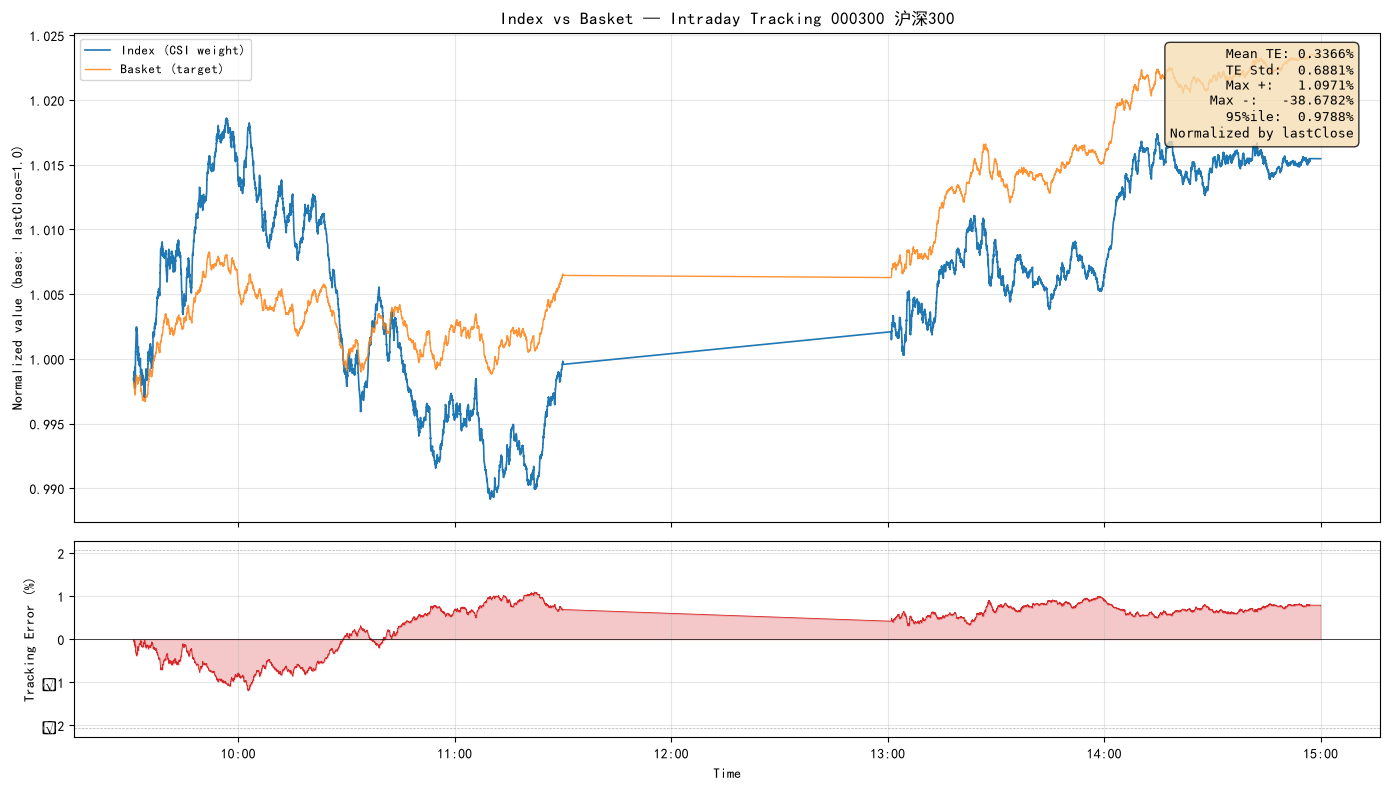

In [21]:
# Task16 — Tick 跟踪误差分析 (lastClose 归一化 + 缓存)


print("=" * 60)
print("Task16: Tick 跟踪误差分析")
print("=" * 60)

_cache_dir = PROJECT_ROOT / "data" / INDEX_CODE / "_tick_cache"
_cache_dir.mkdir(parents=True, exist_ok=True)
_cache_idx = _cache_dir / "index_tick.pkl"
_cache_bkt = _cache_dir / "basket_tick.pkl"

all_stock_codes = df_index_weights["stock_code"].tolist()
weight_dict = dict(zip(df_index_weights["stock_code"], df_index_weights["raw_weight_pct"] / 100.0))

# --- 16A: 指数 tick (缓存) ---
print()
_t0 = time.time()
print(f"  成分股: {len(all_stock_codes)} 只, 权重和: {sum(weight_dict.values()):.4f}")

if _cache_idx.exists():
    print("  [CACHE HIT] 从缓存读取 index_tick...")
    index_tick = pickle.loads(_cache_idx.read_bytes())
    print(f"  指数 tick: {len(index_tick)} ticks (缓存)")
else:
    print("  [CACHE MISS] 从 NAS 读取所有成分股 tick (约 5-10min)...")
    index_tick = build_index_tick(stock_codes=all_stock_codes, weights=weight_dict, build_date_dash=build_date_dash)
    _cache_idx.write_bytes(pickle.dumps(index_tick))
    print(f"  指数 tick 已缓存: {len(index_tick)} ticks")
_t1 = time.time()
print(f"  耗时 {_t1 - _t0:.1f}s")

# --- 16B: 篮子 tick (缓存) ---
print()
df_held = df_target_portfolio[df_target_portfolio["is_held"]].copy()
held_codes = df_held["stock_code"].tolist()
held_qty = dict(zip(df_held["stock_code"], df_held["target_qty"]))
print(f"  持仓股票: {len(held_codes)} 只")

if _cache_bkt.exists():
    print("  [CACHE HIT] 从缓存读取 basket_tick...")
    basket_tick = pickle.loads(_cache_bkt.read_bytes())
    print(f"  篮子 tick: {len(basket_tick)} ticks (缓存)")
else:
    print("  [CACHE MISS] 从 NAS 读取持仓股 tick (约 5-10min)...")
    from utils.reader import read_stocks_ticks as _rts
    _tick_dict = _rts(build_date_dash, held_codes)
    all_btimes = set()
    price_b = {}
    for code in held_codes:
        raw = _tick_dict.get(code)
        if raw is None or raw.empty:
            continue
        # 时间过滤：只保留连续竞价时段（09:30-11:30, 13:00-15:00）
        def _is_cont_time_basket(t):
            hhmmss = str(int(float(t)))[-6:]
            return ("093000" <= hhmmss <= "113000") or ("130000" <= hhmmss <= "150000")
        raw = raw[raw["time"].map(_is_cont_time_basket)]
        ts = raw.drop_duplicates(subset="time", keep="last").set_index("time")["lastPrice"]
        ts = ts[ts > 0]
        if ts.empty:
            continue
        all_btimes.update(ts.index.tolist())
        price_b[code] = ts
    basket_times = sorted(all_btimes)
    basket_tick = pd.Series(0.0, index=basket_times)
    for code, ts in price_b.items():
        qty = held_qty.get(code, 0)
        if qty > 0:
            basket_tick = basket_tick.add(ts.reindex(basket_times).ffill() * qty, fill_value=0)
    _cache_bkt.write_bytes(pickle.dumps(basket_tick))
    print(f"  篮子 tick 已缓存: {len(basket_tick)} ticks")
_t2 = time.time()
print(f"  耗时 {_t2 - _t1:.1f}s")

# 【关键修复】对齐篮子数据到 09:30:00
print("\n[对齐] 将篮子 tick 过滤到 09:30:00...")
def _filter_to_0930(s):
    def _is_0930(t):
        hhmmss = str(int(float(t)))[-6:]
        return ("093000" <= hhmmss <= "113000") or ("130100" <= hhmmss <= "150000")
    return s[s.index.map(_is_0930)]

basket_tick = _filter_to_0930(basket_tick)
print(f"  篮子过滤后: {len(basket_tick)} ticks")
print(f"  篮子首个时刻: {basket_tick.index[0]}")

# --- lastClose 归一化 ---
# 从 tick 数据中取每只股票的 lastClose (昨日收盘价)，加权求和作为归一化基准。
# 意义: 两条线都从"昨日收盘时 1.0"出发，涨幅完全可比。
print()
print("[Normalize] 使用 lastClose 归一化...")
from utils.reader import read_stocks_ticks as _rts2

def _get_lastclose(codes):
    lc = {}
    _td = _rts2(build_date_dash, codes)
    for code in codes:
        raw = _td.get(code)
        if raw is None or raw.empty:
            continue
        vals = raw["lastClose"].dropna()
        vals = vals[vals > 0]
        if not vals.empty:
            lc[code] = float(vals.iloc[0])
    return lc

# 指数归一化基准
_idx_lc = _get_lastclose(all_stock_codes)
_idx_base = sum(weight_dict.get(c, 0) * _idx_lc.get(c, 0) for c in all_stock_codes)
_idx_base_alt = sum(weight_dict.get(c, 0) * _idx_lc.get(c, 0) for c in _idx_lc)
_idx_base = _idx_base_alt if _idx_base_alt > 0 else _idx_base
print(f"  指数归一化基准 (CSI weight * lastClose): {_idx_base:.2f}")

# 篮子归一化基准
_bkt_lc = _get_lastclose(held_codes)
_bkt_base = sum(held_qty.get(c, 0) * _bkt_lc.get(c, 0) for c in held_codes)
_bkt_base_alt = sum(held_qty.get(c, 0) * _bkt_lc.get(c, 0) for c in _bkt_lc)
_bkt_base = _bkt_base_alt if _bkt_base_alt > 0 else _bkt_base
print(f"  篮子归一化基准 (target_qty * lastClose): {_bkt_base:.2f}")

# 执行归一化
_index_tick_norm = index_tick / _idx_base
_basket_tick_norm = basket_tick / _bkt_base

# --- 16C: 计算跟踪误差 (传入已归一化的序列) ---
print()
print("[16C] 计算跟踪误差...")
te_series, te_stats = compute_tracking_error(_index_tick_norm, _basket_tick_norm)
print(f"  跟踪误差统计:")
print(f"    均值:      {te_stats['te_mean_pct']:+.4f}%")
print(f"    标准差:    {te_stats['te_std_pct']:.4f}%")
print(f"    最大正偏离: {te_stats['te_max_positive_pct']:+.4f}%")
print(f"    最大负偏离: {te_stats['te_max_negative_pct']:+.4f}%")
print(f"    95% 分位:   {te_stats['te_pct95_pct']:.4f}%")
print(f"    tick 数:    {te_stats['n_ticks']}")

# --- 16D: 画图 ---
print()
print("[16D] 绘制跟踪误差图...")
fig = plot_tracking(_index_tick_norm, _basket_tick_norm, te_series, te_stats, f"{INDEX_CODE} {index_name}")
# display(fig)
_t3 = time.time()
print(f"Task16 完成, 总耗时 {_t3 - _t0:.1f}s")
